In [ ]:
# =========================================================
# COMPUTER VISION ASSIGNMENT 3
# PCB Defect Detection
# =========================================================

# Name: Ali Hussain
# Roll 22F-3794
# Section: BS(EE)-8A
# Course: CS4059 - Introduction to Computer Vision

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, datasets
from torch.amp import GradScaler, autocast          #  new API (replaces torch.cuda.amp)
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
print("Device:", device)

Device: cpu


In [ ]:
DATASET_PATH = r"D:\datasets\PCB_DATASET\images"

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
# Load full dataset with train transforms
full_dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transforms)
print("Classes:", full_dataset.classes)
print("Total Images:", len(full_dataset))

# Split indices
train_size = int(0.7 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

indices = list(range(len(full_dataset)))
train_idx = indices[:train_size]
val_idx   = indices[train_size:train_size + val_size]
test_idx  = indices[train_size + val_size:]

#  FIX: Use separate dataset objects for val/test so transforms don't conflict
train_dataset = Subset(datasets.ImageFolder(DATASET_PATH, transform=train_transforms), train_idx)
val_dataset   = Subset(datasets.ImageFolder(DATASET_PATH, transform=test_transforms),  val_idx)
test_dataset  = Subset(datasets.ImageFolder(DATASET_PATH, transform=test_transforms),  test_idx)

#  SPEED: num_workers + pin_memory for faster data loading
NUM_WORKERS = 4 if os.name != 'nt' else 0   # Windows has issues with >0 workers sometimes

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']
Total Images: 693
Train: 485 | Val: 103 | Test: 105


D:\Anaconda\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


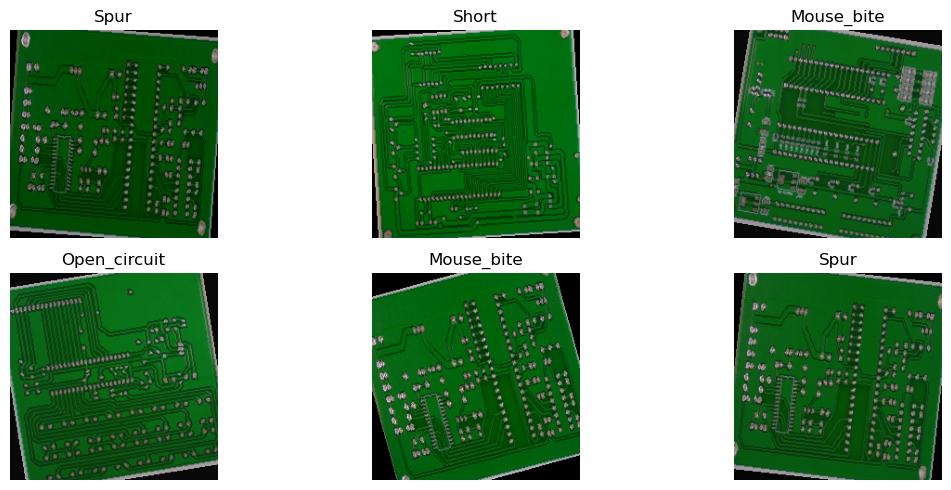

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 5))
for i in range(6):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5          # un-normalize
    img = np.clip(img, 0, 1)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(full_dataset.classes[labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#PART A — CNN

In [ ]:
class PCB_CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1),nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = PCB_CNN(len(full_dataset.classes)).to(device)
print("Total Parameters:", sum(p.numel() for p in model.parameters()))

Total Parameters: 14419206


In [ ]:
from torch.amp import GradScaler, autocast   # ✅ correct import at TOP of this cell

def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    scaler = GradScaler('cuda', enabled=device.type == 'cuda')   # ✅ fixed

    train_losses, val_losses = [], []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=device.type == 'cuda'):   # ✅ fixed
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

                with autocast('cuda', enabled=device.type == 'cuda'):   # ✅ fixed
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_acc = 100 * correct / total
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | "
              f"Val Acc: {val_acc:.2f}% | "
              f"LR: {current_lr:.6f}")

    print("✅ Best model saved as best_model.pth")
    return train_losses, val_losses

In [ ]:
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=30)

Epoch [01/30] Train Loss: 12.4499 | Val Loss: 15.9255 | Val Acc: 0.00% | LR: 0.001000
Epoch [02/30] Train Loss: 6.1273 | Val Loss: 7.7294 | Val Acc: 0.00% | LR: 0.001000
Epoch [03/30] Train Loss: 4.2333 | Val Loss: 4.8751 | Val Acc: 0.00% | LR: 0.001000
Epoch [04/30] Train Loss: 3.0899 | Val Loss: 3.2666 | Val Acc: 0.00% | LR: 0.001000
Epoch [05/30] Train Loss: 2.1605 | Val Loss: 3.2796 | Val Acc: 0.00% | LR: 0.001000
Epoch [06/30] Train Loss: 1.8297 | Val Loss: 2.9439 | Val Acc: 0.00% | LR: 0.001000
Epoch [07/30] Train Loss: 1.6582 | Val Loss: 3.2654 | Val Acc: 0.00% | LR: 0.001000
Epoch [08/30] Train Loss: 1.6255 | Val Loss: 3.3229 | Val Acc: 0.00% | LR: 0.001000
Epoch [09/30] Train Loss: 1.5581 | Val Loss: 3.7044 | Val Acc: 0.00% | LR: 0.001000
Epoch [10/30] Train Loss: 1.5745 | Val Loss: 3.8236 | Val Acc: 0.00% | LR: 0.000500
Epoch [11/30] Train Loss: 1.5529 | Val Loss: 3.7373 | Val Acc: 0.00% | LR: 0.000500
Epoch [12/30] Train Loss: 1.5248 | Val Loss: 3.7098 | Val Acc: 0.00% | LR:

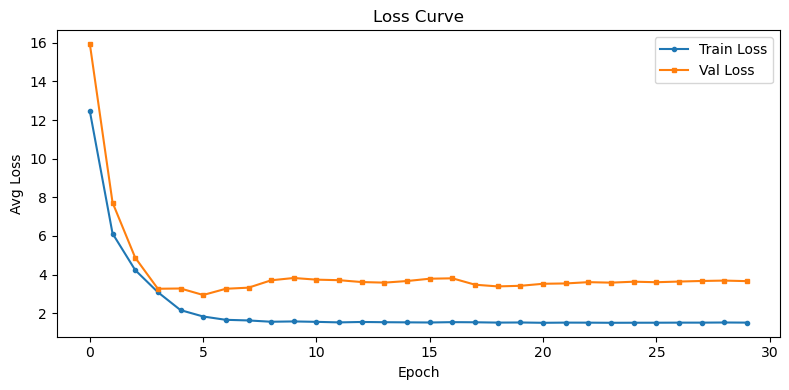

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss", marker='o', markersize=3)
plt.plot(val_losses,   label="Val Loss",   marker='s', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Avg Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#PART B — RESNET

In [ ]:
# ✅ 64x64 instead of 224x224 = 12x fewer pixels to process
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
PIN_MEMORY  = torch.cuda.is_available()
NUM_WORKERS = 0    # ✅ 0 is fastest on Windows

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,  batch_size=32,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset, batch_size=32,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1    = nn.Conv2d(in_c, out_c, 3, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_c)
        self.conv2    = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_c)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_c, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        shortcut = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.relu(x + shortcut)

In [ ]:
class PCB_ResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # ✅ Very small channels for slow PC
        self.layer1 = ResidualBlock(3, 16)
        self.layer2 = ResidualBlock(16, 32)
        self.layer3 = ResidualBlock(32, 64)
        self.pool   = nn.MaxPool2d(2)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(self.layer1(x))
        x = self.pool(self.layer2(x))
        x = self.pool(self.layer3(x))
        x = self.gap(x).view(x.size(0), -1)
        return self.fc(x)

In [ ]:
resnet_model = PCB_ResNet(len(full_dataset.classes)).to(device)
print("ResNet Parameters:", sum(p.numel() for p in resnet_model.parameters()))

ResNet Parameters: 75526


In [ ]:
resnet_train_losses, resnet_val_losses = train_model(
    resnet_model, train_loader, val_loader, epochs=15  # ✅ 15 enough for small model
)

Epoch [01/15] Train Loss: 1.6167 | Val Loss: 2.1539 | Val Acc: 0.00% | LR: 0.001000
Epoch [02/15] Train Loss: 1.5515 | Val Loss: 2.6459 | Val Acc: 0.00% | LR: 0.001000
Epoch [03/15] Train Loss: 1.5241 | Val Loss: 3.0667 | Val Acc: 0.00% | LR: 0.001000
Epoch [04/15] Train Loss: 1.4972 | Val Loss: 3.3420 | Val Acc: 0.00% | LR: 0.001000
Epoch [05/15] Train Loss: 1.4975 | Val Loss: 2.7185 | Val Acc: 0.00% | LR: 0.000500
Epoch [06/15] Train Loss: 1.4852 | Val Loss: 3.9402 | Val Acc: 0.00% | LR: 0.000500
Epoch [07/15] Train Loss: 1.4786 | Val Loss: 4.3284 | Val Acc: 0.00% | LR: 0.000500
Epoch [08/15] Train Loss: 1.4818 | Val Loss: 4.0352 | Val Acc: 0.00% | LR: 0.000500
Epoch [09/15] Train Loss: 1.4789 | Val Loss: 4.1381 | Val Acc: 0.00% | LR: 0.000250
Epoch [10/15] Train Loss: 1.4691 | Val Loss: 4.0257 | Val Acc: 0.00% | LR: 0.000250
Epoch [11/15] Train Loss: 1.4948 | Val Loss: 3.9937 | Val Acc: 0.00% | LR: 0.000250
Epoch [12/15] Train Loss: 1.4696 | Val Loss: 4.4684 | Val Acc: 0.00% | LR: 0

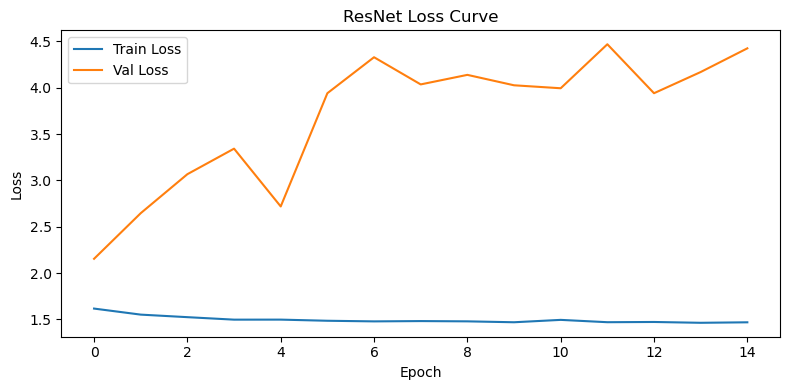

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(resnet_train_losses, label="Train Loss")
plt.plot(resnet_val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def evaluate(model, loader, class_names):
    model.load_state_dict(torch.load("best_model.pth", map_location=device))
    model.eval()

    preds, labels_list = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())  # FIXED

    print("Total predictions:", len(preds))

    cm = confusion_matrix(labels_list, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names,
                cmap='Blues')

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    plt.savefig("confusion_matrix.png")  # optional
    plt.show()